# TP 7 : Dask Dataframe et Machine learning distribué

## Exercice 2 Distributed Training

On utilise les mêmes données que pour l'exercice précédent.

Le code suivant charge un fichier Parquet de training et entraine un modèle `SGDRegressor` à l'aide de `scikit-learn` sur ce jeu de données avec pour cible le prix.

In [44]:
import pandas as pd
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import time

In [45]:
# Chargement les données
df_train = pd.read_parquet("data/houses_1000000.parquet")
df_test = pd.read_parquet("data/houses_50000.parquet")

In [46]:
# Définition des features et de la cible
X_train = df_train[["surface", "chambres", "distance_centre", "anciennete"]]
y_train = df_train["prix"]
X_test = df_test[["surface", "chambres", "distance_centre", "anciennete"]]
y_test = df_test["prix"]

In [47]:
# Entraînement avec SGDRegressor
model = SGDRegressor(max_iter=1)
n_epochs = 50
test_r2 = []

In [48]:
for epoch in range(n_epochs):
    # print(f"Epoch {epoch + 1}/{n_epochs}")
    model.partial_fit(X_train, y_train)  # Passe incrémental sur toutes les données
    
    # Calcul du R2 à chaque époque
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    test_r2.append(r2_score(y_test, y_pred))

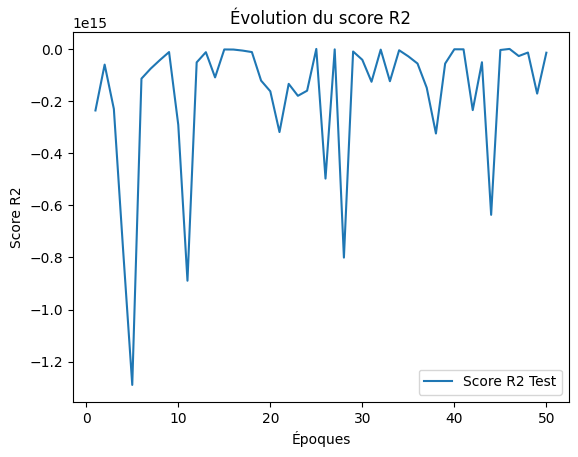

In [49]:
# Visualisation de l'évolution du `r2`
plt.plot(range(1, n_epochs + 1), test_r2, label="Score R2 Test")
plt.xlabel("Époques")
plt.ylabel("Score R2")
plt.legend()
plt.title("Évolution du score R2")
plt.show()

### Question 1
1. Observer les temps de restitution de l'entrainement pour différentes tailles de jeu de données

In [50]:
d_trains = ["data/houses_20000.parquet", "data/houses_50000.parquet", 
            "data/houses_100000.parquet", "data/houses_500000.parquet",
            "data/houses_1000000.parquet", "data/houses_10000000.parquet"]
d_tests = ["data/houses_10000.parquet", "data/houses_20000.parquet", 
           "data/houses_50000.parquet", "data/houses_100000.parquet", 
           "data/houses_500000.parquet", "data/houses_1000000.parquet"]

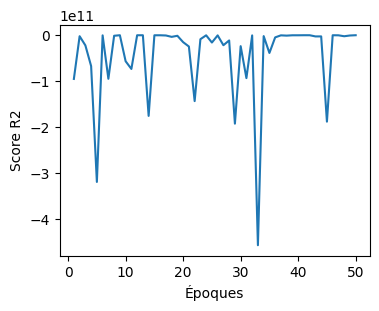

In [67]:
times = []

for i in range(len(d_trains)):
    test_r2 = []
    tic = time.time()
    # Chargement les données
    df_train = pd.read_parquet(d_trains[i])
    df_test = pd.read_parquet(d_tests[i])

    # Définition des features et de la cible
    X_train = df_train[["surface", "chambres", "distance_centre", "anciennete"]]
    y_train = df_train["prix"]
    X_test = df_test[["surface", "chambres", "distance_centre", "anciennete"]]
    y_test = df_test["prix"]

    for epoch in range(n_epochs):
        # print(f"Epoch {epoch + 1}/{n_epochs}")
        model.partial_fit(X_train, y_train)  # Passe incrémental sur toutes les données
        
        # Calcul du R2 à chaque époque
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        test_r2.append(r2_score(y_test, y_pred))

    toc = time.time()
    times.append(toc - tic)

# Visualisation de l'évolution du `r2`
plt.figure(figsize=(4, 3))
plt.plot(range(1, n_epochs + 1), test_r2, label="Score R2 Test")
plt.xlabel("Époques")
plt.ylabel("Score R2")
plt.show()

/tmp/ipykernel_55307/2632855530.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


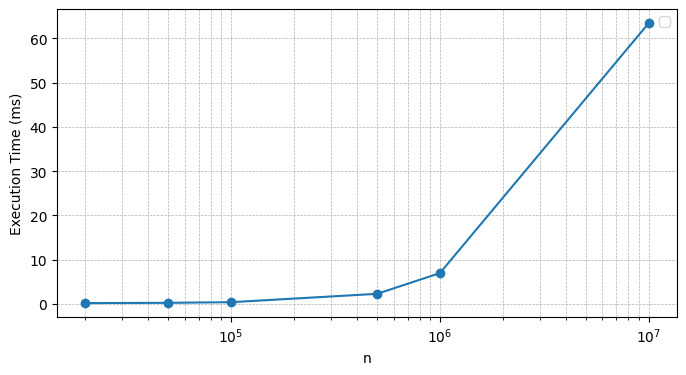

In [68]:
N_values = []
for i in d_trains:

    parts = i.split("_")
    parts2 = parts[-1].split(".")
    N = int(parts2[0])  

    N_values.append(N)

plt.figure(figsize=(8, 4))
plt.plot(N_values, times, marker='o')
plt.xlabel('n')
plt.xscale('log')
plt.ylabel('Execution Time (ms)')
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Les apprentissages et les tests ont été effectués sur des paires d’ensembles de données dont la taille augmente progressivement. Le temps de execution des modèles augmente considérablement dans les ensembles de données à grande échelle.
  </p>
</div>

### Question 2
Utiliser Dask dataframe pour distribuer le jeu de données et adapter l'entrainement sur le jeu de donner distribuer :
    
1. *Mapper* le  `partial_fit` sur le dask dataframe 
2. Réduire les poids, pour simplifier le développement on se propose de réduire suivant la moyenne
3. Comparer les temps de restitution avec la version initiale
4. Proposer des optimisations

In [53]:
import dask.dataframe as dd

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but SGDRegress

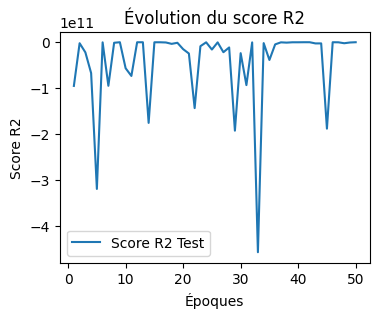

Times per epoch: [0.15360188484191895, 0.14855122566223145, 0.18966269493103027, 0.20231342315673828, 0.5253510475158691, 0.8825116157531738]


In [ ]:
times_dd = []

# Fonction pour entraîner sur chaque partition
def train_on_partition(df_partition, model, X_columns, y_column):
    X = df_partition[X_columns]
    y = df_partition[y_column]
    
    # Appliquer partial_fit sur la partition
    model.partial_fit(X, y)
    return model

# Boucle sur chaque jeu de données
for i in range(len(d_trains)):
    tic = time.time()
    
    # Chargement des données avec Dask
    dd_train = dd.read_parquet(d_trains[i])
    df_test = pd.read_parquet(d_tests[i])  # Les données de test peuvent rester avec Pandas pour simplicité

    # Définition des features et de la cible
    X_columns = ["surface", "chambres", "distance_centre", "anciennete"]
    y_column = "prix"
    
    X_test = df_test[X_columns].values  # Convertir en Pandas pour évaluation
    y_test = df_test[y_column].values  # Convertir en Pandas pour évaluation

    # Entraînement sur plusieurs époques avec Dask
    for epoch in range(n_epochs):
        # Appliquer train_on_partition à chaque partition de Dask
        dd_train.map_partitions(train_on_partition, model=model, X_columns=X_columns, y_column=y_column)
        
        # Calcul du R2 sur les données de test
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        # print(f"Epoch {epoch + 1}/{n_epochs} - R2: {r2}")

    toc = time.time()
    times_dd.append(toc - tic)

# Visualisation de l'évolution du `r2`
plt.figure(figsize=(4, 3))
plt.plot(range(1, n_epochs + 1), test_r2, label="Score R2 Test")
plt.xlabel("Époques")
plt.ylabel("Score R2")
plt.legend()
plt.title("Évolution du score R2")
plt.show()

# Calcul des temps d'exécution
print(f"Times per epoch: {times_dd}")


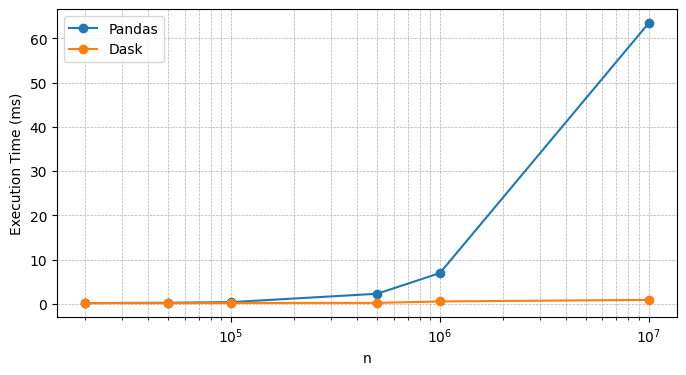

/tmp/ipykernel_55307/4088816171.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


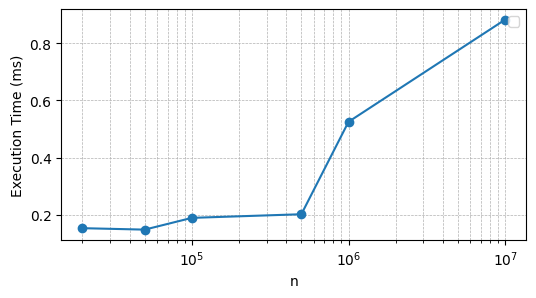

In [72]:
plt.figure(figsize=(8, 4))
plt.plot(N_values, times, marker='o', label=f'Pandas')
plt.plot(N_values, times_dd, marker='o', label=f'Dask')
plt.xlabel('n')
plt.xscale('log')
plt.ylabel('Execution Time (ms)')
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

plt.figure(figsize=(6, 3))
plt.plot(N_values, times_dd, marker='o')
plt.xlabel('n')
plt.xscale('log')
plt.ylabel('Execution Time (ms)')
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Nous pouvons constater que l'application de la carte pour entraîner le modèle a considérablement réduit le temps d'exécution du code, plaçant même les ensembles de données à plus grande échelle à un niveau d'efficacité proche des ensembles de données les plus petits.
  </p>
  <p>
    La parallélisation horizontale effectuée provoque la mise à jour du modèle à chaque fois que chaque batch est formé par un worker différent.
  </p>
</div>


In [74]:
# from dask_jobqueue import SLURMCluster

# cluster = SLURMCluster(cores = 192,
#                        processes = 24,
#                        memory = '500GB',
#                        walltime = '00:30:00',
#                        queue = 'debug')